Daten laden + Qualitätscheck + Baseline-Bereinigung

In [3]:
# ============================================================
# Zelle 1 — Daten laden + Qualitätscheck + Baseline-Bereinigung
# ============================================================

import numpy as np
import pandas as pd

# -------------------------
# 1) Daten einlesen 
# -------------------------
df_raw = pd.read_csv("Marktkampagne.csv", sep=None, engine="python", encoding="utf-8")
df = df_raw.copy()

# Datum sauber parsen (Format: TT-MM-JJJJ)
df["Datum_Kunde"] = pd.to_datetime(df["Datum_Kunde"], format="%d-%m-%Y", errors="coerce")

# -------------------------
# 2) Baseline-Checks (vor Bereinigung)
# -------------------------
print("\n=== DATEN-ÜBERBLICK (RAW) ===")
print(f"Zeilen/Spalten: {df.shape[0]} / {df.shape[1]}")
print(f"Eindeutige IDs: {df['ID'].nunique()} von {len(df)} (sollte identisch sein)")
print(f"Fehlende Einkommen (vorher): {df['Einkommen'].isna().sum()}")
print(f"Datum_Kunde NaT (Parse-Fehler): {df['Datum_Kunde'].isna().sum()}")
print()

# -------------------------
# 3) Familienstand harmonisieren
# -------------------------
familienstand_map = {
    "Allein": "Ledig",
    "Absurd": "Sonstiges",
    "Man lebt nur einmal": "Sonstiges"
}
familienstand_vor = df["Familienstand"].copy()
df["Familienstand"] = df["Familienstand"].replace(familienstand_map)
familienstand_geaendert = (familienstand_vor != df["Familienstand"]).sum()

# -------------------------
# 4) Einkommen: Ausreißer behandeln (robust)
#    - sehr niedrig: unter 1%-Quantil
#    - extrem hoch: > 200.000 (harte Plausibilitätsgrenze)
# -------------------------
income = df["Einkommen"]
q01 = income.quantile(0.01)
q99 = income.quantile(0.99)
high_cap = 200_000

mask_low = income.notna() & (income < q01)
mask_high = income.notna() & (income > high_cap)

df.loc[mask_low | mask_high, "Einkommen"] = np.nan

# -------------------------
# 5) Geburtsjahr plausibilisieren (Alter 18–90)
# -------------------------
stichtag = pd.Timestamp("2026-01-29")
alter = stichtag.year - df["Geburtsjahr"]
mask_alter_unplausibel = alter.notna() & ((alter < 18) | (alter > 90))

df.loc[mask_alter_unplausibel, "Geburtsjahr"] = np.nan

# -------------------------
# 6) Kaufzählungen: Konsistenz herstellen
#    Rabattkäufe <= Summe(Web+Katalog+Laden)
# -------------------------
kanal_kaeufe = df["Anzahl_Webkäufe"] + df["Anzahl_Katalogkäufe"] + df["Anzahl_Ladeneinkäufe"]
mask_rabatt_inkonsistent = df["Anzahl_Rabattkäufe"] > kanal_kaeufe
df.loc[mask_rabatt_inkonsistent, "Anzahl_Rabattkäufe"] = kanal_kaeufe[mask_rabatt_inkonsistent]

# -------------------------
# 7) Praktische Flags für spätere Analyse
# -------------------------
ausgaben_spalten = [c for c in df.columns if c.startswith("Ausgaben_")]
df["Ausgaben_Gesamt"] = df[ausgaben_spalten].sum(axis=1)
df["Kanal_Käufe_Gesamt"] = kanal_kaeufe
df["Flag_Ausgaben_ohne_Käufe"] = (df["Ausgaben_Gesamt"] > 0) & (df["Kanal_Käufe_Gesamt"] == 0)

# -------------------------
# 8) Kurzreport (nach Bereinigung)
# -------------------------
print("=== BEREINIGUNGS-REPORT (CLEAN BASELINE) ===")
print(f"Familienstand angepasst (Anzahl Werte): {familienstand_geaendert}")
print(f"Einkommen: 1%-Quantil = {q01:,.1f} | 99%-Quantil = {q99:,.1f}")
print(f"Einkommen als Ausreißer -> NaN gesetzt: niedrig={mask_low.sum()} | hoch={mask_high.sum()}")
print(f"Fehlende Einkommen (nachher): {df['Einkommen'].isna().sum()}")
print(f"Geburtsjahr unplausibel (Alter <18 oder >90) -> NaN gesetzt: {mask_alter_unplausibel.sum()}")
print(f"Rabattkäufe gekappt (Rabatt > Kanal-Käufe): {mask_rabatt_inkonsistent.sum()}")
print(f"Flag_Ausgaben_ohne_Käufe (Ausgaben > 0 bei Käufe=0): {df['Flag_Ausgaben_ohne_Käufe'].sum()}")
print()

print("=== FAMILIENSTAND (TOP) ===")
print(df["Familienstand"].value_counts().head(10))



=== DATEN-ÜBERBLICK (RAW) ===
Zeilen/Spalten: 2240 / 27
Eindeutige IDs: 2240 von 2240 (sollte identisch sein)
Fehlende Einkommen (vorher): 24
Datum_Kunde NaT (Parse-Fehler): 0

=== BEREINIGUNGS-REPORT (CLEAN BASELINE) ===
Familienstand angepasst (Anzahl Werte): 7
Einkommen: 1%-Quantil = 7,579.2 | 99%-Quantil = 94,458.8
Einkommen als Ausreißer -> NaN gesetzt: niedrig=23 | hoch=1
Fehlende Einkommen (nachher): 48
Geburtsjahr unplausibel (Alter <18 oder >90) -> NaN gesetzt: 3
Rabattkäufe gekappt (Rabatt > Kanal-Käufe): 3
Flag_Ausgaben_ohne_Käufe (Ausgaben > 0 bei Käufe=0): 6

=== FAMILIENSTAND (TOP) ===
Familienstand
Verheiratet       864
Zusammenlebend    580
Ledig             483
Geschieden        232
Verwitwet          77
Sonstiges           4
Name: count, dtype: int64


Deal-Target + Pipeline (sichtbar) + Diagramme

Deal-Schwelle (Rabattanteil): 0.4
Deal-Rate (Anteil 1): 0.22321428571428573


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('prep', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains spa


ROC-AUC: 0.9364080459770114
PR-AUC: 0.7776026522156176

Beste Schwelle (F0.5): 0.85
{'precision': 0.8615384615384616, 'recall': 0.56, 'f1': 0.6787878787878788, 'f0_5': 0.7777777777777778, 'positives_pred': 65}
Confusion Matrix:
 [[339   9]
 [ 44  56]]

Report:
               precision    recall  f1-score   support

           0       0.89      0.97      0.93       348
           1       0.86      0.56      0.68       100

    accuracy                           0.88       448
   macro avg       0.87      0.77      0.80       448
weighted avg       0.88      0.88      0.87       448



<Figure size 640x480 with 0 Axes>

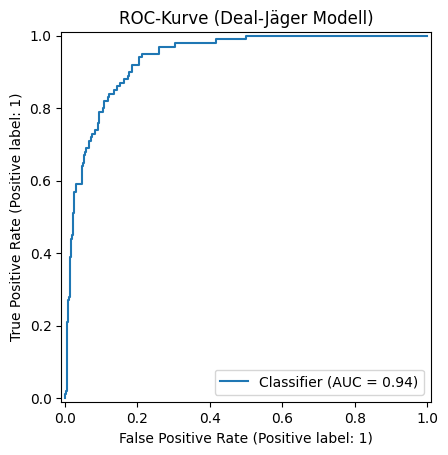

<Figure size 640x480 with 0 Axes>

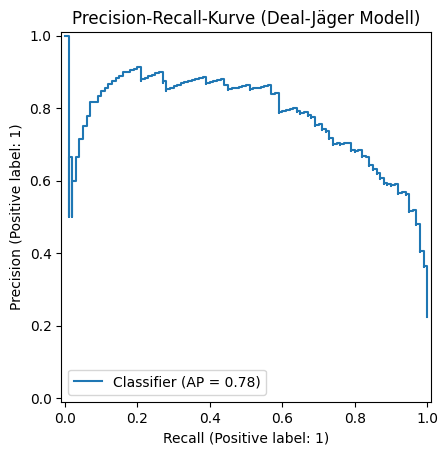

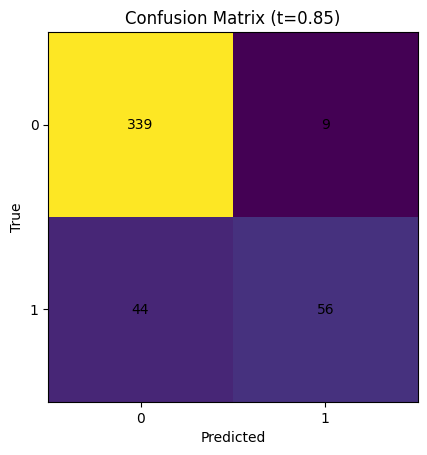

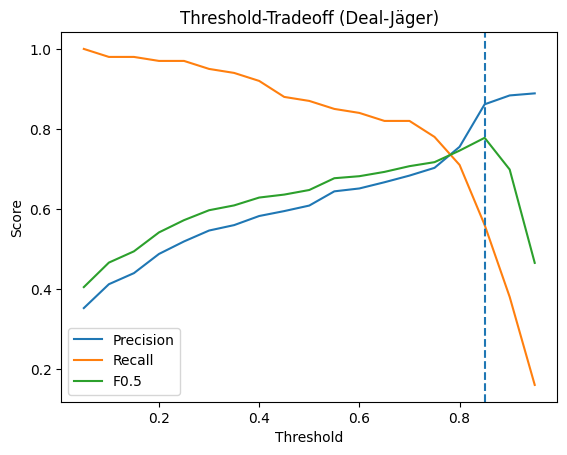

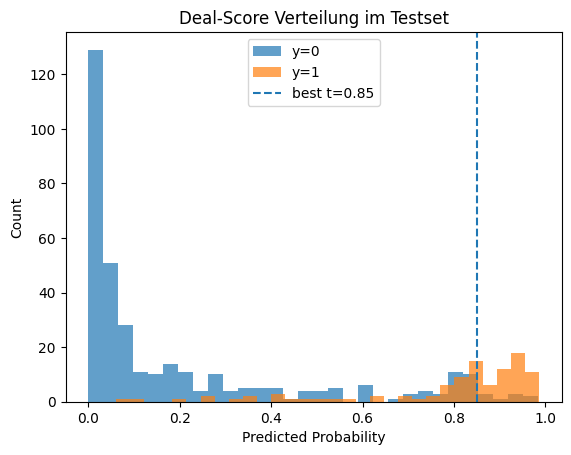


Top Deal-Jäger (erste 20):


,ID,Deal_Score
21,5376,0.998182
383,3310,0.988749
148,5885,0.988749
613,6222,0.986257
311,2826,0.986257
1558,6642,0.984960
2019,2375,0.984482
137,9579,0.983708
607,8477,0.983659
455,4148,0.983611


In [5]:
# ============================================================
# Zelle 2 — Deal-Target + Pipeline (sichtbar) + Diagramme
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

from sklearn import set_config
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    precision_score, recall_score, f1_score, fbeta_score,
    confusion_matrix, classification_report,
    RocCurveDisplay, PrecisionRecallDisplay
)

# -------------------------
# 0) Pipeline-Diagramm aktivieren (Jupyter zeigt dann hübsch an)
# -------------------------
set_config(display="diagram")

# -------------------------
# 1) Hilfsgrößen für Deal-Target
# -------------------------
df["Kaeufe_Gesamt"] = df["Anzahl_Webkäufe"] + df["Anzahl_Katalogkäufe"] + df["Anzahl_Ladeneinkäufe"]

df["Rabattanteil"] = (
    df["Anzahl_Rabattkäufe"] / df["Kaeufe_Gesamt"].replace(0, np.nan)
).clip(upper=1.0).fillna(0.0)

# -------------------------
# 2) Deal-Target (Top-20% Rabattanteil)
# -------------------------
deal_thr = df["Rabattanteil"].quantile(0.80)
df["Ziel_DealJaeger"] = (df["Rabattanteil"] >= deal_thr).astype(int)

print("Deal-Schwelle (Rabattanteil):", float(deal_thr))
print("Deal-Rate (Anteil 1):", float(df["Ziel_DealJaeger"].mean()))

# -------------------------
# 3) Features bauen (Leakage vermeiden)
# -------------------------
drop_cols = [
    "ID", "Datum_Kunde", "Ziel_DealJaeger",
    "Anzahl_Rabattkäufe", "Rabattanteil", "Kaeufe_Gesamt"
]
X_deal = df.drop(columns=[c for c in drop_cols if c in df.columns])
y_deal = df["Ziel_DealJaeger"]

cat_cols = X_deal.select_dtypes(include="object").columns.tolist()
num_cols = [c for c in X_deal.columns if c not in cat_cols]

# -------------------------
# 4) Train/Test Split
# -------------------------
Xtr, Xte, ytr, yte = train_test_split(
    X_deal, y_deal, test_size=0.2, random_state=42, stratify=y_deal
)

# -------------------------
# 5) Preprocessing (Imputer, weil wir NaNs erzeugt haben)
# -------------------------
num_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

cat_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", num_pipe, num_cols),
        ("cat", cat_pipe, cat_cols),
    ],
    remainder="drop"
)

# -------------------------
# 6) Modell (Baseline)
# -------------------------
model_deal = Pipeline(steps=[
    ("prep", preprocess),
    ("clf", LogisticRegression(max_iter=3000, class_weight="balanced"))
])

# Pipeline "ansehen" (Jupyter Diagramm)
display(model_deal)

model_deal.fit(Xtr, ytr)
proba_deal = model_deal.predict_proba(Xte)[:, 1]

roc = roc_auc_score(yte, proba_deal)
prauc = average_precision_score(yte, proba_deal)
print("\nROC-AUC:", roc)
print("PR-AUC:", prauc)

# -------------------------
# 7) Threshold-Optimierung (F0.5 -> Precision wichtiger)
# -------------------------
thresholds = np.linspace(0.05, 0.95, 19)

rows = []
best = {"t": None, "precision": None, "recall": None, "f1": None, "f0_5": -1, "positives_pred": None}

for t in thresholds:
    pred = (proba_deal >= t).astype(int)
    p = precision_score(yte, pred, zero_division=0)
    r = recall_score(yte, pred, zero_division=0)
    f1 = f1_score(yte, pred, zero_division=0)
    f05 = fbeta_score(yte, pred, beta=0.5, zero_division=0)
    pp = int(pred.sum())

    rows.append((float(t), float(p), float(r), float(f1), float(f05), pp))

    if f05 > best["f0_5"]:
        best = {"t": float(t), "precision": float(p), "recall": float(r), "f1": float(f1), "f0_5": float(f05), "positives_pred": pp}

pred_best = (proba_deal >= best["t"]).astype(int)
cm = confusion_matrix(yte, pred_best)

print("\nBeste Schwelle (F0.5):", best["t"])
print({"precision": best["precision"], "recall": best["recall"], "f1": best["f1"], "f0_5": best["f0_5"], "positives_pred": best["positives_pred"]})
print("Confusion Matrix:\n", cm)
print("\nReport:\n", classification_report(yte, pred_best))

# -------------------------
# 8) Deal-Score + Flag für alle Kunden
# -------------------------
proba_all = model_deal.predict_proba(X_deal)[:, 1]
df["Deal_Score"] = proba_all
df["Deal_Flag"] = (df["Deal_Score"] >= best["t"]).astype(int)

# -------------------------
# 9) Diagramme (ROC, PR, Confusion, Threshold-Kurve, Score-Verteilung)
# -------------------------

# (A) ROC-Kurve
plt.figure()
RocCurveDisplay.from_predictions(yte, proba_deal)
plt.title("ROC-Kurve (Deal-Jäger Modell)")
plt.show()

# (B) Precision-Recall-Kurve
plt.figure()
PrecisionRecallDisplay.from_predictions(yte, proba_deal)
plt.title("Precision-Recall-Kurve (Deal-Jäger Modell)")
plt.show()

# (C) Confusion Matrix als Heatmap (matplotlib-only)
plt.figure()
plt.imshow(cm, interpolation="nearest")
plt.title(f"Confusion Matrix (t={best['t']:.2f})")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.xticks([0, 1], ["0", "1"])
plt.yticks([0, 1], ["0", "1"])
for i in range(2):
    for j in range(2):
        plt.text(j, i, str(cm[i, j]), ha="center", va="center")
plt.show()

# (D) Threshold-Tradeoff: Precision / Recall / F0.5
ts = np.array([r[0] for r in rows])
prec = np.array([r[1] for r in rows])
rec = np.array([r[2] for r in rows])
f05 = np.array([r[4] for r in rows])

plt.figure()
plt.plot(ts, prec, label="Precision")
plt.plot(ts, rec, label="Recall")
plt.plot(ts, f05, label="F0.5")
plt.axvline(best["t"], linestyle="--")
plt.title("Threshold-Tradeoff (Deal-Jäger)")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.legend()
plt.show()

# (E) Score-Verteilung (Testset) nach Klasse
plt.figure()
plt.hist(proba_deal[yte.values == 0], bins=30, alpha=0.7, label="y=0")
plt.hist(proba_deal[yte.values == 1], bins=30, alpha=0.7, label="y=1")
plt.axvline(best["t"], linestyle="--", label=f"best t={best['t']:.2f}")
plt.title("Deal-Score Verteilung im Testset")
plt.xlabel("Predicted Probability")
plt.ylabel("Count")
plt.legend()
plt.show()

# -------------------------
# 10) Top-Liste anzeigen
# -------------------------
deal_top = df.loc[df["Deal_Flag"] == 1, ["ID", "Deal_Score"]].sort_values("Deal_Score", ascending=False)
print("\nTop Deal-Jäger (erste 20):")
display(deal_top.head(20))


CROSS-SELL + Pipeline (sichtbar) + Diagramme

Cross-Zielspalte: Ausgaben_Fisch
Cross-Schwelle: 65.0
Cross-Rate (Anteil 1): 0.20625


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('prep', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains spa


ROC-AUC: 0.9783524670249145
PR-AUC: 0.9180216651376609

Beste Schwelle (F0.5): 0.75
{'precision': 0.9066666666666666, 'recall': 0.7391304347826086, 'f1': 0.8143712574850299, 'f0_5': 0.8673469387755102, 'positives_pred': 75}
Confusion Matrix:
 [[349   7]
 [ 24  68]]

Report:
               precision    recall  f1-score   support

           0       0.94      0.98      0.96       356
           1       0.91      0.74      0.81        92

    accuracy                           0.93       448
   macro avg       0.92      0.86      0.89       448
weighted avg       0.93      0.93      0.93       448



,threshold,precision,recall,f1,f0_5,positives_pred
14,0.75,0.906667,0.739130,0.814371,0.867347,75
15,0.80,0.925373,0.673913,0.779874,0.861111,67
13,0.70,0.844444,0.826087,0.835165,0.840708,90
12,0.65,0.800000,0.869565,0.833333,0.813008,100
16,0.85,0.925926,0.543478,0.684932,0.811688,54
11,0.60,0.783019,0.902174,0.838384,0.804264,106
10,0.55,0.745614,0.923913,0.825243,0.775547,114
17,0.90,0.950000,0.413043,0.575758,0.753968,40
9,0.50,0.715447,0.956522,0.818605,0.753425,123
8,0.45,0.681818,0.978261,0.803571,0.725806,132


<Figure size 640x480 with 0 Axes>

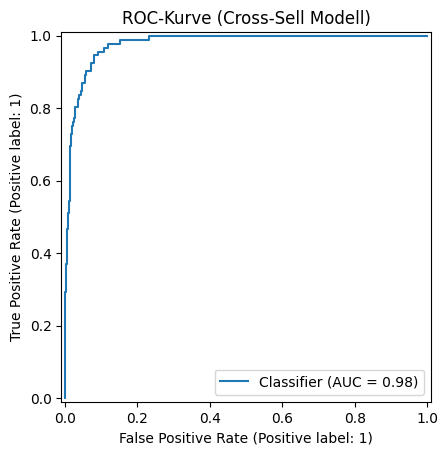

<Figure size 640x480 with 0 Axes>

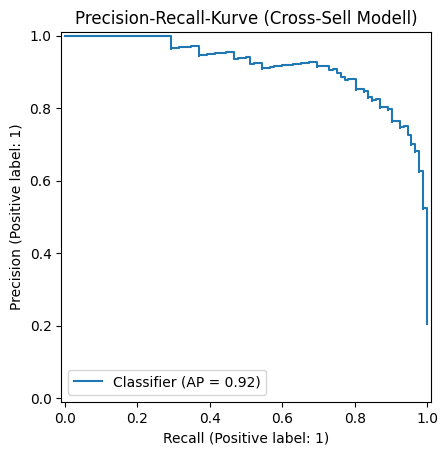

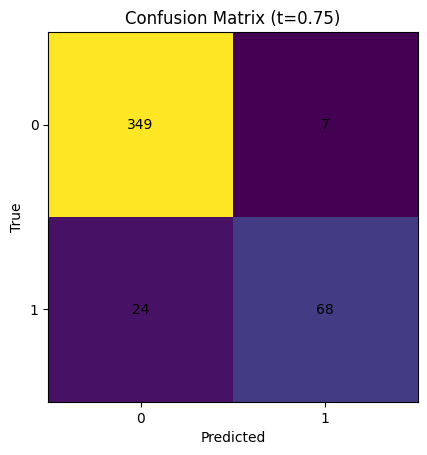

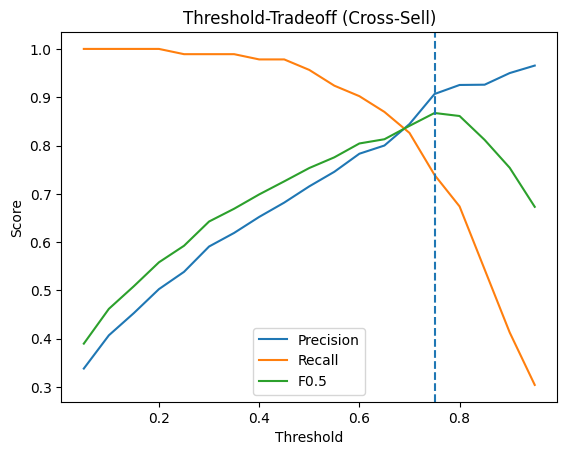

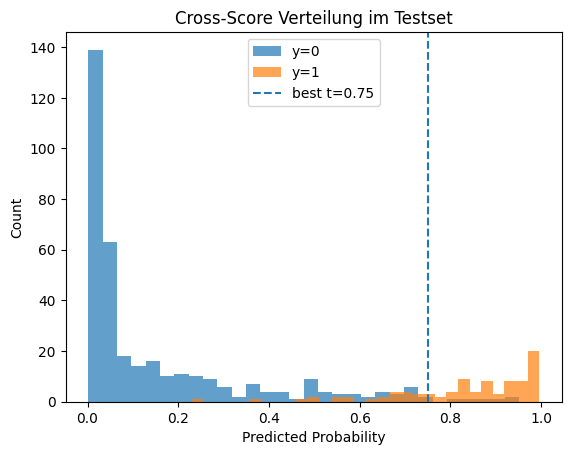


Top Cross-Kandidaten (erste 20):


,ID,Cross_Score
1601,5453,0.998891
1199,7342,0.998819
2096,7428,0.998335
1444,1553,0.997085
924,8931,0.996665
360,7274,0.996640
1259,2147,0.996010
305,9274,0.995882
1521,8643,0.995816
1157,1077,0.995430


In [6]:
# ============================================================
# Zelle 3 — CROSS-SELL + Pipeline (sichtbar) + Diagramme
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display
from sklearn import set_config
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    precision_score, recall_score, f1_score, fbeta_score,
    confusion_matrix, classification_report,
    RocCurveDisplay, PrecisionRecallDisplay
)

# -------------------------
# 0) Pipeline-Diagramm aktivieren (Jupyter zeigt die Pipeline hübsch)
# -------------------------
set_config(display="diagram")

# -------------------------
# 1) Sicherheits-Check: df muss aus Zelle 1 existieren
# -------------------------
if "df" not in globals():
    raise NameError("df ist nicht definiert. Bitte zuerst Zelle 1 ausführen (Daten laden + Cleaning).")

# Datum notfalls sauber machen (falls df aus anderem Schritt kommt)
if not np.issubdtype(df["Datum_Kunde"].dtype, np.datetime64):
    df["Datum_Kunde"] = pd.to_datetime(df["Datum_Kunde"], dayfirst=True, errors="coerce")

# -------------------------
# 2) Mini-Features (ohne harte Imputation -> Imputer in der Pipeline!)
# -------------------------
df["Einkommen_fehlte"] = df["Einkommen"].isna().astype(int)

stichtag = df["Datum_Kunde"].max()
df["Kundendauer_Tage"] = (stichtag - df["Datum_Kunde"]).dt.days

# -------------------------
# 3) Ziel-Kategorie auswählen (automatisch)
# -------------------------
prioritaet = [
    "Ausgaben_Fisch", "Ausgaben_Wein", "Ausgaben_Fleisch", "Ausgaben_Gold", "Ausgaben_Süßes",
    "MntFishProducts", "MntWines", "MntMeatProducts", "MntGoldProds", "MntSweetProducts"
]

spend_cols = [c for c in df.columns if c.lower().startswith("ausgaben_")]
if not spend_cols:
    spend_cols = [c for c in df.columns if c.startswith("Mnt")]

if not spend_cols:
    raise ValueError("Keine passenden Ausgaben-Spalten gefunden (weder 'Ausgaben_*' noch 'Mnt*').")

cross_col = next((c for c in prioritaet if c in df.columns), None)
if cross_col is None:
    cross_col = spend_cols[0]  # fallback

print("Cross-Zielspalte:", cross_col)

# -------------------------
# 4) Cross-Target bauen (Top-20% in dieser Kategorie)
# -------------------------
nonzero = df[cross_col].fillna(0) > 0

if nonzero.mean() >= 0.20:
    cross_thr = df[cross_col].quantile(0.80)
    df["Ziel_Cross"] = (df[cross_col] >= cross_thr).astype(int)
else:
    cross_thr = df.loc[nonzero, cross_col].quantile(0.80)
    df["Ziel_Cross"] = ((df[cross_col] >= cross_thr) & nonzero).astype(int)

print("Cross-Schwelle:", float(cross_thr))
print("Cross-Rate (Anteil 1):", float(df["Ziel_Cross"].mean()))

# -------------------------
# 5) Features bauen (Leakage vermeiden!)
#    cross_col MUSS raus, weil es das Ziel direkt verrät.
# -------------------------
drop_cols = ["ID", "Datum_Kunde", "Ziel_Cross", cross_col]
X_cross = df.drop(columns=[c for c in drop_cols if c in df.columns])
y_cross = df["Ziel_Cross"]

cat_cols = X_cross.select_dtypes(include="object").columns.tolist()
num_cols = [c for c in X_cross.columns if c not in cat_cols]

# -------------------------
# 6) Train/Test Split
# -------------------------
Xtr, Xte, ytr, yte = train_test_split(
    X_cross, y_cross, test_size=0.2, random_state=42, stratify=y_cross
)

# -------------------------
# 7) Preprocessing (WICHTIG: Imputer, weil wir NaNs haben können!)
# -------------------------
num_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

cat_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", num_pipe, num_cols),
        ("cat", cat_pipe, cat_cols),
    ],
    remainder="drop"
)

# -------------------------
# 8) Modell (Baseline)
# -------------------------
model_cross = Pipeline(steps=[
    ("prep", preprocess),
    ("clf", LogisticRegression(max_iter=3000, class_weight="balanced")),
])

# Pipeline ansehen (Diagramm)
display(model_cross)

model_cross.fit(Xtr, ytr)
proba_cross = model_cross.predict_proba(Xte)[:, 1]

roc = roc_auc_score(yte, proba_cross)
prauc = average_precision_score(yte, proba_cross)
print("\nROC-AUC:", roc)
print("PR-AUC:", prauc)

# -------------------------
# 9) Threshold-Optimierung (F0.5 -> Precision wichtiger)
# -------------------------
thresholds = np.linspace(0.05, 0.95, 19)

rows = []
best = {"t": None, "precision": None, "recall": None, "f1": None, "f0_5": -1, "positives_pred": None}

for t in thresholds:
    pred = (proba_cross >= t).astype(int)
    p = precision_score(yte, pred, zero_division=0)
    r = recall_score(yte, pred, zero_division=0)
    f1 = f1_score(yte, pred, zero_division=0)
    f05 = fbeta_score(yte, pred, beta=0.5, zero_division=0)
    pp = int(pred.sum())

    rows.append((float(t), float(p), float(r), float(f1), float(f05), pp))

    if f05 > best["f0_5"]:
        best = {
            "t": float(t),
            "precision": float(p),
            "recall": float(r),
            "f1": float(f1),
            "f0_5": float(f05),
            "positives_pred": pp
        }

pred_best = (proba_cross >= best["t"]).astype(int)
cm = confusion_matrix(yte, pred_best)

print("\nBeste Schwelle (F0.5):", best["t"])
print({"precision": best["precision"], "recall": best["recall"], "f1": best["f1"], "f0_5": best["f0_5"], "positives_pred": best["positives_pred"]})
print("Confusion Matrix:\n", cm)
print("\nReport:\n", classification_report(yte, pred_best))

# Optional: Threshold-Tabelle anzeigen
df_thr = pd.DataFrame(rows, columns=["threshold", "precision", "recall", "f1", "f0_5", "positives_pred"])
display(df_thr.sort_values("f0_5", ascending=False).head(10))

# -------------------------
# 10) Cross-Score + Flag für alle Kunden
# -------------------------
proba_all = model_cross.predict_proba(X_cross)[:, 1]
df["Cross_Score"] = proba_all
df["Cross_Flag"] = (df["Cross_Score"] >= best["t"]).astype(int)

# -------------------------
# 11) Diagramme (ROC, PR, Confusion, Threshold-Tradeoff, Score-Verteilung)
# -------------------------

# (A) ROC-Kurve
plt.figure()
RocCurveDisplay.from_predictions(yte, proba_cross)
plt.title("ROC-Kurve (Cross-Sell Modell)")
plt.show()

# (B) Precision-Recall-Kurve
plt.figure()
PrecisionRecallDisplay.from_predictions(yte, proba_cross)
plt.title("Precision-Recall-Kurve (Cross-Sell Modell)")
plt.show()

# (C) Confusion Matrix (matplotlib-only)
plt.figure()
plt.imshow(cm, interpolation="nearest")
plt.title(f"Confusion Matrix (t={best['t']:.2f})")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.xticks([0, 1], ["0", "1"])
plt.yticks([0, 1], ["0", "1"])
for i in range(2):
    for j in range(2):
        plt.text(j, i, str(cm[i, j]), ha="center", va="center")
plt.show()

# (D) Threshold-Tradeoff
ts = df_thr["threshold"].values
prec = df_thr["precision"].values
rec = df_thr["recall"].values
f05 = df_thr["f0_5"].values

plt.figure()
plt.plot(ts, prec, label="Precision")
plt.plot(ts, rec, label="Recall")
plt.plot(ts, f05, label="F0.5")
plt.axvline(best["t"], linestyle="--")
plt.title("Threshold-Tradeoff (Cross-Sell)")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.legend()
plt.show()

# (E) Score-Verteilung (Testset) nach Klasse
plt.figure()
plt.hist(proba_cross[yte.values == 0], bins=30, alpha=0.7, label="y=0")
plt.hist(proba_cross[yte.values == 1], bins=30, alpha=0.7, label="y=1")
plt.axvline(best["t"], linestyle="--", label=f"best t={best['t']:.2f}")
plt.title("Cross-Score Verteilung im Testset")
plt.xlabel("Predicted Probability")
plt.ylabel("Count")
plt.legend()
plt.show()

# -------------------------
# 12) Top-Liste anzeigen
# -------------------------
cross_top = df.loc[df["Cross_Flag"] == 1, ["ID", "Cross_Score"]].sort_values("Cross_Score", ascending=False)

print("\nTop Cross-Kandidaten (erste 20):")
display(cross_top.head(20))


CLUSTERING (KMeans) + k-Suche + Diagramme + Profiling

Clustering-Features:
 - numerisch: 32
 - kategorisch: 3
 - inklusive Scores: ['Deal_Score', 'Cross_Score']

Bestes k (Silhouette-max): 2


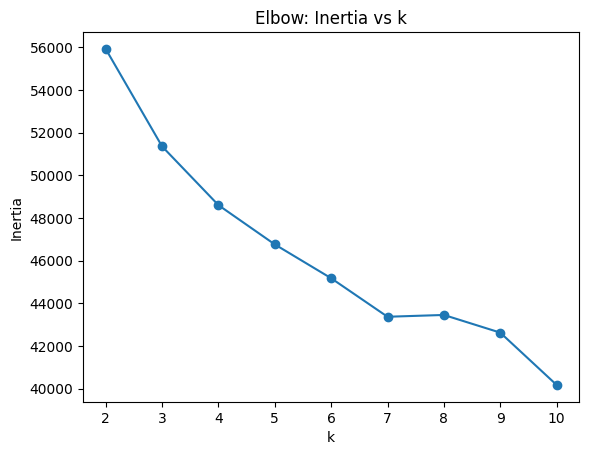

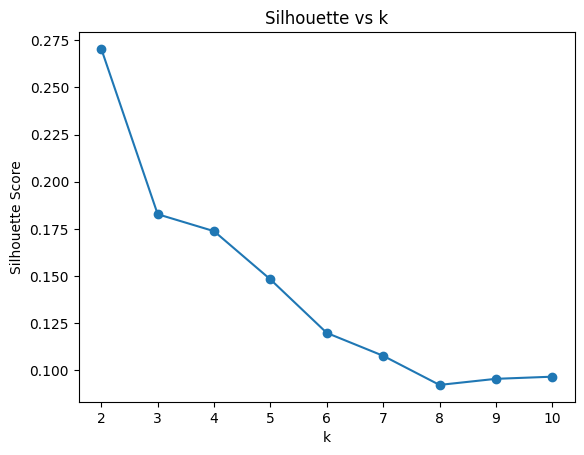

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('prep', ...), ('kmeans', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains 


Cluster-Größen:
Cluster
0    1289
1     951
Name: count, dtype: int64


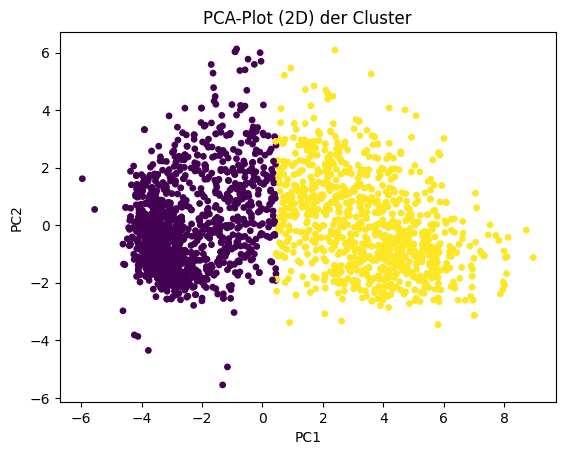


Cluster-Profil (Mittelwerte):


,Einkommen,Geburtsjahr,Kundendauer_Tage,Ausgaben_Gesamt,Kanal_Käufe_Gesamt,Deal_Score,Cross_Score,Cluster_Size,Deal_Flag_Rate,Cross_Flag_Rate
Cluster,,,,,,,,,,
0,38557.135891,1980.301476,339.259891,169.123351,7.411947,0.544348,0.056400,1289,0.238945,0.00000
1,70920.066950,1977.005263,374.941115,1197.674027,19.483701,0.065330,0.624177,951,0.005258,0.42061



Top 5 pro Cluster nach: Score_Summe


,ID,Cluster,Score_Summe,Deal_Score,Cross_Score
1788,1513,1,1.789228,0.833561,0.955667
432,238,1,1.741776,0.767791,0.973985
335,10151,1,1.655351,0.833489,0.821861
21,5376,1,1.612973,0.998182,0.614791
107,2683,1,1.535605,0.828608,0.706996
969,3933,0,1.232125,0.606487,0.625637
1399,10490,0,1.148551,0.788011,0.360540
2110,9729,0,1.122145,0.942077,0.180067
888,8825,0,1.117934,0.862995,0.254939
772,8897,0,1.091123,0.967364,0.123759


In [8]:
# ============================================================
# Zelle 5 — CLUSTERING (KMeans) + k-Suche + Diagramme + Profiling
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display
from sklearn import set_config
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

set_config(display="diagram")

# -------------------------
# 0) df muss existieren
# -------------------------
if "df" not in globals():
    raise NameError("df ist nicht definiert. Bitte zuerst Zelle 1 ausführen (Daten laden + Cleaning).")

# -------------------------
# 1) Optionale Komfort-Features (falls noch nicht vorhanden)
# -------------------------
if "Datum_Kunde" in df.columns and not np.issubdtype(df["Datum_Kunde"].dtype, np.datetime64):
    df["Datum_Kunde"] = pd.to_datetime(df["Datum_Kunde"], dayfirst=True, errors="coerce")

if "Kundendauer_Tage" not in df.columns and "Datum_Kunde" in df.columns:
    stichtag = df["Datum_Kunde"].max()
    df["Kundendauer_Tage"] = (stichtag - df["Datum_Kunde"]).dt.days

# Ausgaben_Gesamt falls nicht da (summe Ausgaben_*)
ausgaben_spalten = [c for c in df.columns if c.startswith("Ausgaben_")]
if "Ausgaben_Gesamt" not in df.columns and len(ausgaben_spalten) > 0:
    df["Ausgaben_Gesamt"] = df[ausgaben_spalten].sum(axis=1)

# Kanal_Käufe_Gesamt falls nicht da
kanal_cols = ["Anzahl_Webkäufe", "Anzahl_Katalogkäufe", "Anzahl_Ladeneinkäufe"]
if "Kanal_Käufe_Gesamt" not in df.columns and all(c in df.columns for c in kanal_cols):
    df["Kanal_Käufe_Gesamt"] = df[kanal_cols].sum(axis=1)

# -------------------------
# 2) Feature-Auswahl (robust + sinnvoll)
#    - ID / Zielspalten raus
#    - Flags optional raus (für Cluster lieber Scores, nicht harte Labels)
# -------------------------
exclude = set()
for c in df.columns:
    if c == "ID":
        exclude.add(c)
    if c.startswith("Ziel_"):
        exclude.add(c)
    if c in ["Ziel_DealJaeger", "Ziel_Cross"]:
        exclude.add(c)
    if c in ["Deal_Flag", "Cross_Flag"]:
        exclude.add(c)  # fürs Profiling behalten wir sie später, aber nicht fürs Clustering
    if c == "Datum_Kunde":
        exclude.add(c)

# Deal/Cross Scores (wenn vorhanden) bewusst reinnehmen, weil das „Brücke“ zu deinen 2 MLs ist
# Falls nicht vorhanden: kein Stress, dann clustern wir ohne.
include_scores = [c for c in ["Deal_Score", "Cross_Score", "Opportunity_Score"] if c in df.columns]

# Kandidaten = alle Spalten außer exclude
cand_cols = [c for c in df.columns if c not in exclude]

X = df[cand_cols].copy()

# cat/num split
cat_cols = X.select_dtypes(include="object").columns.tolist()
num_cols = [c for c in X.columns if c not in cat_cols]

print("Clustering-Features:")
print(" - numerisch:", len(num_cols))
print(" - kategorisch:", len(cat_cols))
if include_scores:
    print(" - inklusive Scores:", include_scores)

# -------------------------
# 3) Preprocessing (Imputer + Scaler + OneHot)
# -------------------------
num_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

cat_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", num_pipe, num_cols),
        ("cat", cat_pipe, cat_cols),
    ],
    remainder="drop"
)

# Preprocess einmal fitten (damit alle k vergleichbar sind)
X_prep = preprocess.fit_transform(X)
X_dense = X_prep.toarray() if hasattr(X_prep, "toarray") else X_prep

# -------------------------
# 4) k-Suche: Elbow (Inertia) + Silhouette
# -------------------------
ks = list(range(2, 11))
inertias, sils = [], []

for k in ks:
    km = KMeans(n_clusters=k, n_init="auto", random_state=42)
    labels = km.fit_predict(X_dense)
    inertias.append(km.inertia_)
    sils.append(silhouette_score(X_dense, labels))

best_k = ks[int(np.argmax(sils))]
print("\nBestes k (Silhouette-max):", best_k)

# Diagramm: Inertia + Silhouette
plt.figure()
plt.plot(ks, inertias, marker="o")
plt.title("Elbow: Inertia vs k")
plt.xlabel("k")
plt.ylabel("Inertia")
plt.show()

plt.figure()
plt.plot(ks, sils, marker="o")
plt.title("Silhouette vs k")
plt.xlabel("k")
plt.ylabel("Silhouette Score")
plt.show()

# -------------------------
# 5) Finales KMeans mit best_k
# -------------------------
kmeans_final = KMeans(n_clusters=best_k, n_init="auto", random_state=42)
clusters = kmeans_final.fit_predict(X_dense)
df["Cluster"] = clusters

# Optional: Pipeline „ansehen“
cluster_pipe = Pipeline(steps=[("prep", preprocess), ("kmeans", kmeans_final)])
display(cluster_pipe)

print("\nCluster-Größen:")
print(df["Cluster"].value_counts().sort_index())

# -------------------------
# 6) PCA-Plot (2D) zur Visualisierung
# -------------------------
pca = PCA(n_components=2, random_state=42)
X_2d = pca.fit_transform(X_dense)

plt.figure()
plt.scatter(X_2d[:, 0], X_2d[:, 1], c=df["Cluster"].values, s=15)
plt.title("PCA-Plot (2D) der Cluster")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

# -------------------------
# 7) Cluster-Profiling (Business-Insights)
#    - Mittelwerte wichtiger Kennzahlen
#    - Deal/Cross Raten (falls vorhanden)
# -------------------------
profile_cols = []
for c in ["Einkommen", "Geburtsjahr", "Kundendauer_Tage", "Ausgaben_Gesamt", "Kanal_Käufe_Gesamt",
          "Anzahl_Webbesuche", "Anzahl_Beschwerden", "Deal_Score", "Cross_Score", "Opportunity_Score"]:
    if c in df.columns:
        profile_cols.append(c)

# Deal/Cross Flags (nur fürs Profiling)
extra_rate_cols = []
for c in ["Deal_Flag", "Cross_Flag"]:
    if c in df.columns:
        extra_rate_cols.append(c)

grp = df.groupby("Cluster")

profile = grp[profile_cols].mean(numeric_only=True)
sizes = grp.size().rename("Cluster_Size")
profile = profile.join(sizes)

# Raten dazunehmen
for c in extra_rate_cols:
    profile[c + "_Rate"] = grp[c].mean()

profile = profile.sort_values("Cluster_Size", ascending=False)
print("\nCluster-Profil (Mittelwerte):")
display(profile)

# -------------------------
# 8) Top-Kunden je Cluster (nach Opportunity oder Summe Scores)
# -------------------------
rank_col = None
if "Opportunity_Score" in df.columns:
    rank_col = "Opportunity_Score"
elif all(c in df.columns for c in ["Deal_Score", "Cross_Score"]):
    df["Score_Summe"] = df["Deal_Score"] + df["Cross_Score"]
    rank_col = "Score_Summe"
elif "Deal_Score" in df.columns:
    rank_col = "Deal_Score"
elif "Cross_Score" in df.columns:
    rank_col = "Cross_Score"

if rank_col:
    print(f"\nTop 5 pro Cluster nach: {rank_col}")
    top_per_cluster = (
        df.sort_values(rank_col, ascending=False)
          .groupby("Cluster")
          .head(5)[["ID","Cluster",rank_col] + [c for c in ["Deal_Score","Cross_Score"] if c in df.columns]]
    )
    display(top_per_cluster)
else:
    print("\nHinweis: Keine Scores vorhanden zum Ranken. (Deal/Cross erst ausführen, dann bekommst du Top-Listen.)")


Cluster BENENNEN

In [9]:
# ============================================================
# Zelle 6 — Cluster BENENNEN (automatisch) + in df mappen
# Voraussetzung: df["Cluster"] existiert (aus deiner KMeans-Zelle)
# Optional: Deal_Flag/Cross_Flag, Rabattanteil, Deal_Score/Cross_Score existieren (wenn du sie vorher gebaut hast)
# ============================================================

import numpy as np
import pandas as pd
from IPython.display import display
import matplotlib.pyplot as plt

if "Cluster" not in df.columns:
    raise ValueError("df['Cluster'] fehlt. Bitte erst die Clustering-Zelle ausführen.")

# --- Hilfsfeatures (robust) ---
if "Kaeufe_Gesamt" not in df.columns and all(c in df.columns for c in ["Anzahl_Webkäufe","Anzahl_Katalogkäufe","Anzahl_Ladeneinkäufe"]):
    df["Kaeufe_Gesamt"] = df["Anzahl_Webkäufe"] + df["Anzahl_Katalogkäufe"] + df["Anzahl_Ladeneinkäufe"]

if "Rabattanteil" not in df.columns and all(c in df.columns for c in ["Anzahl_Rabattkäufe","Kaeufe_Gesamt"]):
    df["Rabattanteil"] = (
        df["Anzahl_Rabattkäufe"] / df["Kaeufe_Gesamt"].replace(0, np.nan)
    ).clip(upper=1.0).fillna(0.0)

if "Ausgaben_Gesamt" not in df.columns:
    ausgaben_spalten = [c for c in df.columns if c.startswith("Ausgaben_")]
    if ausgaben_spalten:
        df["Ausgaben_Gesamt"] = df[ausgaben_spalten].sum(axis=1)

# Kanal-Anteile
if "Kaeufe_Gesamt" in df.columns:
    df["Anteil_Web"] = (df.get("Anzahl_Webkäufe", 0) / df["Kaeufe_Gesamt"].replace(0, np.nan)).fillna(0.0)
    df["Anteil_Katalog"] = (df.get("Anzahl_Katalogkäufe", 0) / df["Kaeufe_Gesamt"].replace(0, np.nan)).fillna(0.0)
    df["Anteil_Laden"] = (df.get("Anzahl_Ladeneinkäufe", 0) / df["Kaeufe_Gesamt"].replace(0, np.nan)).fillna(0.0)

# --- Kennzahlen, die wir zur Benennung nutzen ---
candidate_metrics = [
    "Ausgaben_Gesamt", "Kaeufe_Gesamt", "Kanal_Käufe_Gesamt",
    "Rabattanteil", "Anteil_Web", "Anteil_Laden",
    "Anzahl_Webbesuche", "Anzahl_Beschwerden", "Kundendauer_Tage",
    "Anzahl_Kinder", "Anzahl_Teenager",
    "Deal_Score", "Cross_Score", "Opportunity_Score",
    "Deal_Flag", "Cross_Flag"
]
metrics = [c for c in candidate_metrics if c in df.columns]

if not metrics:
    raise ValueError("Keine passenden Metriken gefunden (z. B. Ausgaben_Gesamt, Rabattanteil, etc.).")

cluster_stats = df.groupby("Cluster")[metrics].mean(numeric_only=True)
cluster_sizes = df.groupby("Cluster").size().rename("Cluster_Size")
cluster_stats = cluster_stats.join(cluster_sizes)

# Z-Scores (relativ zum Gesamtdatensatz) -> hilft bei "hoch/niedrig"
overall_mean = df[metrics].mean(numeric_only=True)
overall_std  = df[metrics].std(numeric_only=True).replace(0, np.nan)

z = (cluster_stats[metrics] - overall_mean) / overall_std
z = z.fillna(0.0)

def _tag_if(metric, cond, tag, tags):
    if metric in z.columns and cond:
        tags.append(tag)

def build_cluster_name(cid):
    tags = []

    # Kern-Logik (robust & business-tauglich)
    _tag_if("Ausgaben_Gesamt", ("Ausgaben_Gesamt" in z.columns and z.loc[cid,"Ausgaben_Gesamt"] > 0.75), "High-Spend", tags)
    _tag_if("Ausgaben_Gesamt", ("Ausgaben_Gesamt" in z.columns and z.loc[cid,"Ausgaben_Gesamt"] < -0.75), "Low-Spend", tags)

    _tag_if("Rabattanteil", ("Rabattanteil" in z.columns and z.loc[cid,"Rabattanteil"] > 0.75), "Dealjäger", tags)
    _tag_if("Rabattanteil", ("Rabattanteil" in z.columns and z.loc[cid,"Rabattanteil"] < -0.75), "Vollpreis", tags)

    _tag_if("Anteil_Web", ("Anteil_Web" in z.columns and z.loc[cid,"Anteil_Web"] > 0.60), "Online-lastig", tags)
    _tag_if("Anteil_Laden", ("Anteil_Laden" in z.columns and z.loc[cid,"Anteil_Laden"] > 0.60), "Store-lastig", tags)

    _tag_if("Kundendauer_Tage", ("Kundendauer_Tage" in z.columns and z.loc[cid,"Kundendauer_Tage"] > 0.75), "Langzeit", tags)
    _tag_if("Kundendauer_Tage", ("Kundendauer_Tage" in z.columns and z.loc[cid,"Kundendauer_Tage"] < -0.75), "Neu", tags)

    _tag_if("Anzahl_Beschwerden", ("Anzahl_Beschwerden" in z.columns and z.loc[cid,"Anzahl_Beschwerden"] > 0.75), "Beschwerde-sensibel", tags)

    # Haushalt
    if "Anzahl_Kinder" in z.columns or "Anzahl_Teenager" in z.columns:
        kids = 0.0
        if "Anzahl_Kinder" in cluster_stats.columns:
            kids += cluster_stats.loc[cid, "Anzahl_Kinder"]
        if "Anzahl_Teenager" in cluster_stats.columns:
            kids += cluster_stats.loc[cid, "Anzahl_Teenager"]
        if kids >= (df.get("Anzahl_Kinder", pd.Series([0]*len(df))).fillna(0).mean()
                    + df.get("Anzahl_Teenager", pd.Series([0]*len(df))).fillna(0).mean()):
            tags.append("Familie")

    # Deal/Cross Rates falls vorhanden
    if "Deal_Flag" in cluster_stats.columns and cluster_stats.loc[cid, "Deal_Flag"] > df["Deal_Flag"].mean() + 0.10:
        tags.append("Deal-Target")
    if "Cross_Flag" in cluster_stats.columns and cluster_stats.loc[cid, "Cross_Flag"] > df["Cross_Flag"].mean() + 0.10:
        tags.append("Cross-Target")

    # Falls noch nichts -> neutrales Label
    if not tags:
        tags = ["Standard"]

    # Kürzen: max 3 Tags, sonst wird's ewig
    tags = tags[:3]
    return " / ".join(tags)

# Namen bauen
name_map = {cid: build_cluster_name(cid) for cid in cluster_stats.index}

# Duplikate vermeiden (wenn zwei Cluster gleiche Tags bekommen)
seen = {}
for cid, name in list(name_map.items()):
    if name in seen:
        name_map[cid] = f"{name} (C{cid})"
    else:
        seen[name] = cid

df["Cluster_Name"] = df["Cluster"].map(name_map)

print("Cluster-Namen:")
for cid in sorted(name_map.keys()):
    print(f" - Cluster {cid}: {name_map[cid]}")

# Profil-Tabelle (mit Name)
profil = cluster_stats.copy()
profil.insert(0, "Cluster_Name", profil.index.map(name_map))
display(profil.sort_values("Cluster_Size", ascending=False))

# Kleine Visualisierung: Cluster-Größen
counts = df.groupby(["Cluster","Cluster_Name"]).size().reset_index(name="n").sort_values("n", ascending=False)
p


Cluster-Namen:
 - Cluster 0: Standard
 - Cluster 1: High-Spend / Vollpreis / Cross-Target


,Cluster_Name,Ausgaben_Gesamt,Kaeufe_Gesamt,Kanal_Käufe_Gesamt,Rabattanteil,Anteil_Web,Anteil_Laden,Kundendauer_Tage,Deal_Score,Cross_Score,Deal_Flag,Cross_Flag,Cluster_Size
Cluster,,,,,,,,,,,,,
0,Standard,169.123351,7.411947,7.411947,0.341040,0.352315,0.551545,339.259891,0.544348,0.056400,0.238945,0.00000,1289
1,High-Spend / Vollpreis / Cross-Target,1197.674027,19.483701,19.483701,0.105521,0.297376,0.439470,374.941115,0.065330,0.624177,0.005258,0.42061,951


0.9655172413793104

Random Forest (Deal ODER Cross) + Pipeline sichtbar + Diagramme + Feature Importances

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('prep', ...), ('rf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains spar


RandomForest — Target=Ziel_DealJaeger
ROC-AUC: 0.9732183908045977
PR-AUC: 0.9117849798063757

Beste Schwelle (F0.5): 0.65
{'precision': 0.8928571428571429, 'recall': 0.75, 'f1': 0.8152173913043478, 'f0_5': 0.8600917431192661, 'positives_pred': 84}
Confusion Matrix:
 [[339   9]
 [ 25  75]]

Report:
               precision    recall  f1-score   support

           0       0.93      0.97      0.95       348
           1       0.89      0.75      0.82       100

    accuracy                           0.92       448
   macro avg       0.91      0.86      0.88       448
weighted avg       0.92      0.92      0.92       448



,threshold,precision,recall,f1,f0_5,positives_pred
12,0.65,0.892857,0.75,0.815217,0.860092,84
13,0.70,0.898734,0.71,0.793296,0.853365,79
11,0.60,0.852632,0.81,0.830769,0.843750,95
10,0.55,0.838384,0.83,0.834171,0.836694,99
9,0.50,0.838384,0.83,0.834171,0.836694,99
14,0.75,0.891892,0.66,0.758621,0.833333,74
8,0.45,0.815534,0.84,0.827586,0.820312,103
15,0.80,0.903226,0.56,0.691358,0.804598,62
7,0.40,0.776786,0.87,0.820755,0.793796,112
16,0.85,0.940000,0.47,0.626667,0.783333,50


<Figure size 640x480 with 0 Axes>

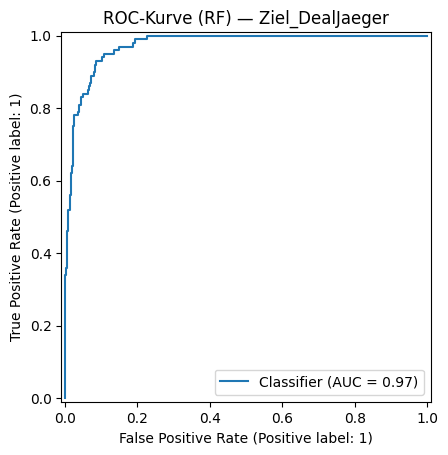

<Figure size 640x480 with 0 Axes>

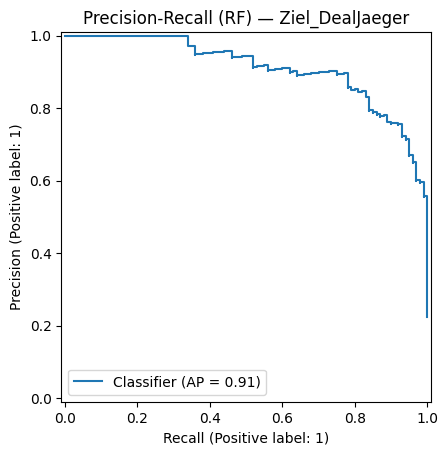

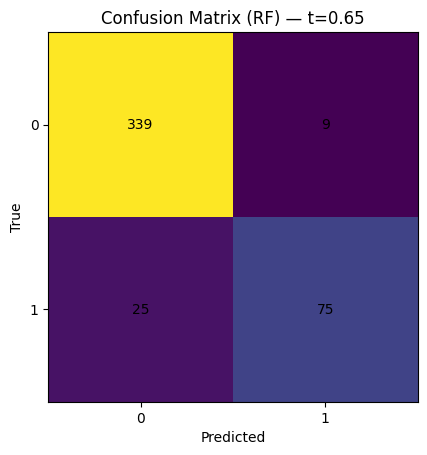

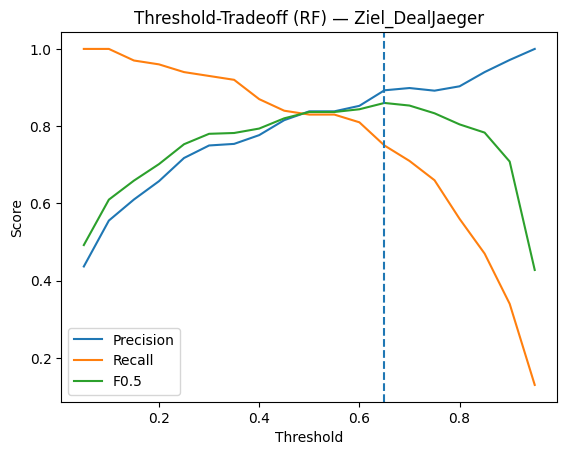

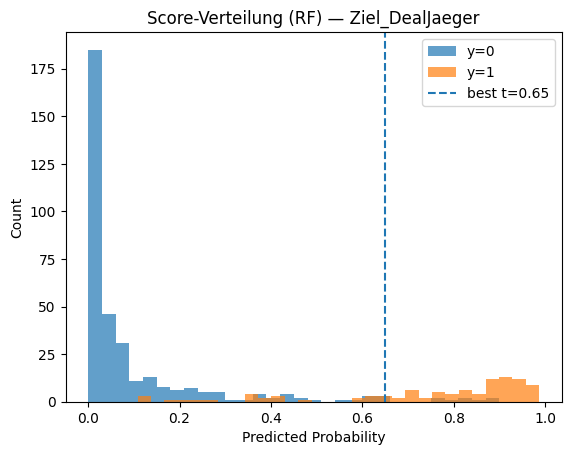


Top 25 Feature Importances:


,feature,importance
25,num__Deal_Score,0.165463
2,num__Kinder_zu_Hause,0.086439
33,num__Score_Summe,0.079736
30,num__Cross_Score,0.076479
23,num__Kanal_Käufe_Gesamt,0.052212
22,num__Ausgaben_Gesamt,0.047042
1,num__Einkommen,0.036800
32,num__Cluster,0.036210
52,cat__Cluster_Name_Standard,0.036203
49,cat__Segment_2D_Deal-only,0.027504


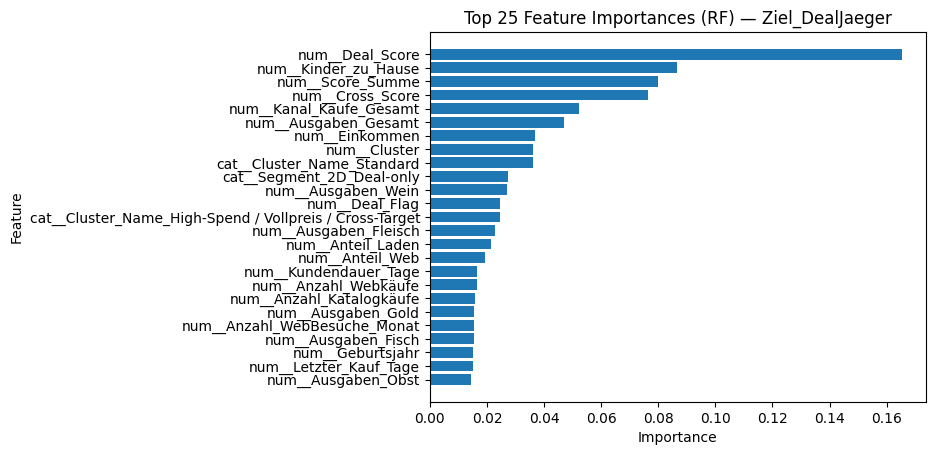


Gespeichert in df: RF_Score_DealJaeger und RF_Flag_DealJaeger


,ID,RF_Score_DealJaeger,RF_Flag_DealJaeger
955,10031,0.995878,1
520,3696,0.995551,1
786,1135,0.994770,1
1596,24,0.994770,1
1604,11092,0.993482,1
2017,10598,0.992817,1
1224,2740,0.992426,1
1263,8147,0.991870,1
2141,9216,0.991280,1
516,11025,0.990896,1


In [10]:
# ============================================================
# Zelle 7 — Random Forest (Deal ODER Cross) + Pipeline sichtbar + Diagramme + Feature Importances
# Du kannst unten einfach TARGET auf "Ziel_DealJaeger" oder "Ziel_Cross" stellen.
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display
from sklearn import set_config
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    precision_score, recall_score, f1_score, fbeta_score,
    confusion_matrix, classification_report,
    RocCurveDisplay, PrecisionRecallDisplay
)

set_config(display="diagram")

# -------------------------
# 0) Target wählen
# -------------------------
TARGET = "Ziel_DealJaeger"   # oder: "Ziel_Cross"

if TARGET not in df.columns:
    raise ValueError(f"{TARGET} fehlt. Bitte erst das passende Target erstellen (Deal- oder Cross-Zelle).")

# -------------------------
# 1) Leakage-Drops je Target
# -------------------------
drop_base = ["ID", "Datum_Kunde", TARGET]

drop_leak = []
if TARGET == "Ziel_DealJaeger":
    drop_leak += ["Anzahl_Rabattkäufe", "Rabattanteil", "Kaeufe_Gesamt"]
if TARGET == "Ziel_Cross":
    # cross_col kennen wir evtl. aus der Cross-Zelle, sonst versuchen wir es zu erkennen:
    if "cross_col" in globals() and isinstance(cross_col, str) and cross_col in df.columns:
        drop_leak += [cross_col]
    else:
        # Notfall: falls eine Cross-Zielspalte bereits als Text irgendwo markiert wurde, lassen wir's leer.
        pass

# Optional: keine Scores als Features, wenn du strikt "ohne Meta" willst.
# (Wenn du sie drin lassen willst: kommentier diese Zeilen einfach aus.)
drop_optional_scores = []  # z.B. ["Deal_Score","Cross_Score","Opportunity_Score"]

drop_cols = [c for c in (drop_base + drop_leak + drop_optional_scores) if c in df.columns]

X = df.drop(columns=drop_cols)
y = df[TARGET].astype(int)

cat_cols = X.select_dtypes(include="object").columns.tolist()
num_cols = [c for c in X.columns if c not in cat_cols]

# -------------------------
# 2) Train/Test Split
# -------------------------
Xtr, Xte, ytr, yte = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# -------------------------
# 3) Preprocess: Imputer + OneHot (RF braucht kein Scaling)
# -------------------------
num_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
])

cat_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", num_pipe, num_cols),
        ("cat", cat_pipe, cat_cols),
    ],
    remainder="drop"
)

# -------------------------
# 4) Random Forest Modell
# -------------------------
rf = RandomForestClassifier(
    n_estimators=600,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced",
    min_samples_leaf=2
)

model_rf = Pipeline(steps=[
    ("prep", preprocess),
    ("rf", rf)
])

# Pipeline sichtbar
display(model_rf)

# Fit + Proba
model_rf.fit(Xtr, ytr)
proba = model_rf.predict_proba(Xte)[:, 1]

roc = roc_auc_score(yte, proba)
prauc = average_precision_score(yte, proba)
print(f"\nRandomForest — Target={TARGET}")
print("ROC-AUC:", roc)
print("PR-AUC:", prauc)

# -------------------------
# 5) Threshold-Optimierung (F0.5 -> Precision wichtiger)
# -------------------------
thresholds = np.linspace(0.05, 0.95, 19)

rows = []
best = {"t": None, "precision": None, "recall": None, "f1": None, "f0_5": -1, "positives_pred": None}

for t in thresholds:
    pred = (proba >= t).astype(int)
    p = precision_score(yte, pred, zero_division=0)
    r = recall_score(yte, pred, zero_division=0)
    f1 = f1_score(yte, pred, zero_division=0)
    f05 = fbeta_score(yte, pred, beta=0.5, zero_division=0)
    pp = int(pred.sum())
    rows.append((float(t), float(p), float(r), float(f1), float(f05), pp))

    if f05 > best["f0_5"]:
        best = {"t": float(t), "precision": float(p), "recall": float(r), "f1": float(f1), "f0_5": float(f05), "positives_pred": pp}

pred_best = (proba >= best["t"]).astype(int)
cm = confusion_matrix(yte, pred_best)

print("\nBeste Schwelle (F0.5):", best["t"])
print({"precision": best["precision"], "recall": best["recall"], "f1": best["f1"], "f0_5": best["f0_5"], "positives_pred": best["positives_pred"]})
print("Confusion Matrix:\n", cm)
print("\nReport:\n", classification_report(yte, pred_best))

df_thr = pd.DataFrame(rows, columns=["threshold","precision","recall","f1","f0_5","positives_pred"])
display(df_thr.sort_values("f0_5", ascending=False).head(10))

# -------------------------
# 6) Diagramme
# -------------------------
plt.figure()
RocCurveDisplay.from_predictions(yte, proba)
plt.title(f"ROC-Kurve (RF) — {TARGET}")
plt.show()

plt.figure()
PrecisionRecallDisplay.from_predictions(yte, proba)
plt.title(f"Precision-Recall (RF) — {TARGET}")
plt.show()

plt.figure()
plt.imshow(cm, interpolation="nearest")
plt.title(f"Confusion Matrix (RF) — t={best['t']:.2f}")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.xticks([0, 1], ["0", "1"])
plt.yticks([0, 1], ["0", "1"])
for i in range(2):
    for j in range(2):
        plt.text(j, i, str(cm[i, j]), ha="center", va="center")
plt.show()

# Threshold-Tradeoff
plt.figure()
plt.plot(df_thr["threshold"], df_thr["precision"], label="Precision")
plt.plot(df_thr["threshold"], df_thr["recall"], label="Recall")
plt.plot(df_thr["threshold"], df_thr["f0_5"], label="F0.5")
plt.axvline(best["t"], linestyle="--")
plt.title(f"Threshold-Tradeoff (RF) — {TARGET}")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.legend()
plt.show()

# Score-Verteilung
plt.figure()
plt.hist(proba[yte.values == 0], bins=30, alpha=0.7, label="y=0")
plt.hist(proba[yte.values == 1], bins=30, alpha=0.7, label="y=1")
plt.axvline(best["t"], linestyle="--", label=f"best t={best['t']:.2f}")
plt.title(f"Score-Verteilung (RF) — {TARGET}")
plt.xlabel("Predicted Probability")
plt.ylabel("Count")
plt.legend()
plt.show()

# -------------------------
# 7) Feature Importances (Top 25, nach OneHot aufgelöst)
# -------------------------
# Feature-Namen aus dem Preprocess ziehen (sklearn >= 1.0)
prep = model_rf.named_steps["prep"]
feature_names = prep.get_feature_names_out()

importances = model_rf.named_steps["rf"].feature_importances_
fi = pd.DataFrame({"feature": feature_names, "importance": importances}).sort_values("importance", ascending=False)

print("\nTop 25 Feature Importances:")
display(fi.head(25))

plt.figure()
plt.barh(fi.head(25)["feature"][::-1], fi.head(25)["importance"][::-1])
plt.title(f"Top 25 Feature Importances (RF) — {TARGET}")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

# -------------------------
# 8) Score + Flag zurück ins df (für alle Kunden)
# -------------------------
proba_all = model_rf.predict_proba(X)[:, 1]
score_col = "RF_Score_" + TARGET.replace("Ziel_", "")
flag_col  = "RF_Flag_"  + TARGET.replace("Ziel_", "")

df[score_col] = proba_all
df[flag_col] = (df[score_col] >= best["t"]).astype(int)

print(f"\nGespeichert in df: {score_col} und {flag_col}")
display(df[["ID", score_col, flag_col]].sort_values(score_col, ascending=False).head(20))
